## Importar librerias

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import style

import seaborn as sns

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

style.use('ggplot') or plt.style.use('ggplot')

## Funciones EDA

In [3]:
def calculos_boxplot(columna, coef=1.5):
    """
    Calcula el Rango Intercuartílico (IQR) y los límites para valores considerados
    válidos (no extremos).
    -------------------------------
    Parametros de entrada:
    - columna: columna de un dataframe o Serie de Pandas
    - coef: valor del coeficiente para el cálculo de los límites válidos, por defecto 1.5
        Se puede ampliar si se quiere "relajar" la exigencia para dichos valores

    -------------------------------
    SALIDA:
    Devuelve una tupla (limite_inferior, limite_superior)
    y muestra por pantalla información

    """

    Q1, Q3 = columna.quantile([0.25,0.75])

    IQR = Q3 - Q1

    lim_inferior = Q1 - coef*IQR
    lim_superior = Q3 + coef*IQR

    print('Cuartiles: ', Q1, '\t', Q3)
    print('IQR: ',IQR)
    print('Limite inferior: ', lim_inferior)
    print('Limite superior: ', lim_superior)

    return lim_inferior, lim_superior


In [4]:
def categoricas_unicos(dataframe, var_cat, vc_out=True):
    """
    Muestra valores unicos y conteo de las variables categóricas.
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_cat: lista de variables categóricas (cadena)
    - vc_out: booleano para mostrar o no (True/False) el resultado de "value_counts()"
        Por defecto lo muestra

    -------------------------------
    SALIDA:
    No devuelve valor. Saca por pantalla la información

    """

    for discreta in var_cat:

        print(f'Variable {discreta.upper()}:')
        print('Valores unicos: ')
        print(dataframe[discreta].unique(), end='\n'*2)

        if vc_out:
            print(dataframe[discreta].value_counts(), end='\n'*2)





In [5]:
def graf_histo_box_numericas(dataframe, var_num):
    """
    Realiza graficas histograma y boxplot de variables numéricas de un dataframe
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_num: lista de variables numéricas (cadena)

    -------------------------------
    SALIDA:
    No devuelve valor. Dibuja las gráficas por pantalla

    """

    TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
                   'tab:gray','tab:olive', 'tab:cyan')

    fig, axes = plt.subplots(len(var_num), 2, \
                             figsize=(20, 5 * len(var_num)), \
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    ax = axes.ravel()

    # graficas distribucion y boxplot de cada atributo
    for idx, atributo in enumerate(var_num):

        # distribucion (histograma)
        sns.histplot(dataframe[atributo], ax=ax[2 * idx], \
                     color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                     alpha=0.15, kde=True)

        # titulo, etiquetas histograma
        ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
        ax[2 * idx].set_xlabel(f'Valores {atributo}')
        ax[2 * idx].set_ylabel("Frequencia")

        # boxplot
        sns.boxplot(x=atributo, data=dataframe, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

        # titulo, etiquetas boxplot
        ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
        ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')



# Lectura archivo

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:

ruta = '/content/drive/MyDrive/ESPECIALISTA IA/house_price (1).csv'

df_house = pd.read_csv(ruta)

df_house.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,yr_built,yr_renovated,zipcode
0,7229300521,231300.0,2,1.00,1180,5650,1.0,0,1955,0,98178
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,1951,1991,98125
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,1933,0,98028
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,1965,0,98136
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,1987,0,98074


### Información, primeras correcciones.

In [8]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            21613 non-null  int64  
 1   price         21613 non-null  float64
 2   bedrooms      21613 non-null  int64  
 3   bathrooms     21613 non-null  float64
 4   sqft_living   21613 non-null  int64  
 5   sqft_lot      21613 non-null  int64  
 6   floors        21613 non-null  float64
 7   waterfront    21613 non-null  int64  
 8   yr_built      21613 non-null  int64  
 9   yr_renovated  21613 non-null  int64  
 10  zipcode       21613 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 1.8 MB


#### Eliminar columna ID

In [9]:
df_house.drop(columns='id', inplace=True)

df_house.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'yr_built', 'yr_renovated', 'zipcode'],
      dtype='object')

#### Ordenar columnas

In [10]:
df_house = df_house[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', \
                     'yr_built', 'yr_renovated', 'zipcode', 'price']]

df_house.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'yr_built', 'yr_renovated', 'zipcode', 'price'],
      dtype='object')

#### Eliminar duplicados

In [11]:
df_house.drop_duplicates(inplace=True)

df_house.duplicated().sum()

np.int64(0)

In [12]:
df_house.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,yr_built,yr_renovated,zipcode,price
count,21605.000000,21605.000000,21605.000000,2.160500e+04,21605.000000,21605.000000,21605.000000,21605.000000,21605.000000,2.160500e+04
mean,3.370840,2.114719,2079.993196,1.511145e+04,1.494029,0.007545,1970.993937,84.341865,98077.938162,5.401003e+05
std,0.930138,0.770279,918.560683,4.142750e+04,0.539829,0.086533,29.369131,401.543673,53.509211,3.671869e+05
min,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,1900.000000,0.000000,98001.000000,7.500000e+04
25%,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,1951.000000,0.000000,98033.000000,3.215000e+05
50%,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,0.000000,1975.000000,0.000000,98065.000000,4.500000e+05
75%,4.000000,2.500000,2550.000000,1.069500e+04,2.000000,0.000000,1997.000000,0.000000,98118.000000,6.450000e+05
max,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,2015.000000,2015.000000,98199.000000,7.700000e+06


- En vistas al EDA devolvemos a esta columna el caracter de texto:

In [13]:
df_house.waterfront = df_house.waterfront.replace({0: 'Sin vistas', 1: 'Con vistas'})

df_house.waterfront.value_counts()

,count
waterfront,
Sin vistas,21442
Con vistas,163


#### "Separar" variables por tipo

In [14]:
var_numericas = df_house.select_dtypes(exclude=['object']).columns.to_list()

var_numericas

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'price']

In [15]:
var_categoricas = df_house.select_dtypes(include=['object']).columns.to_list()

var_categoricas


['waterfront']

# ANALISIS UNIVARIANTE

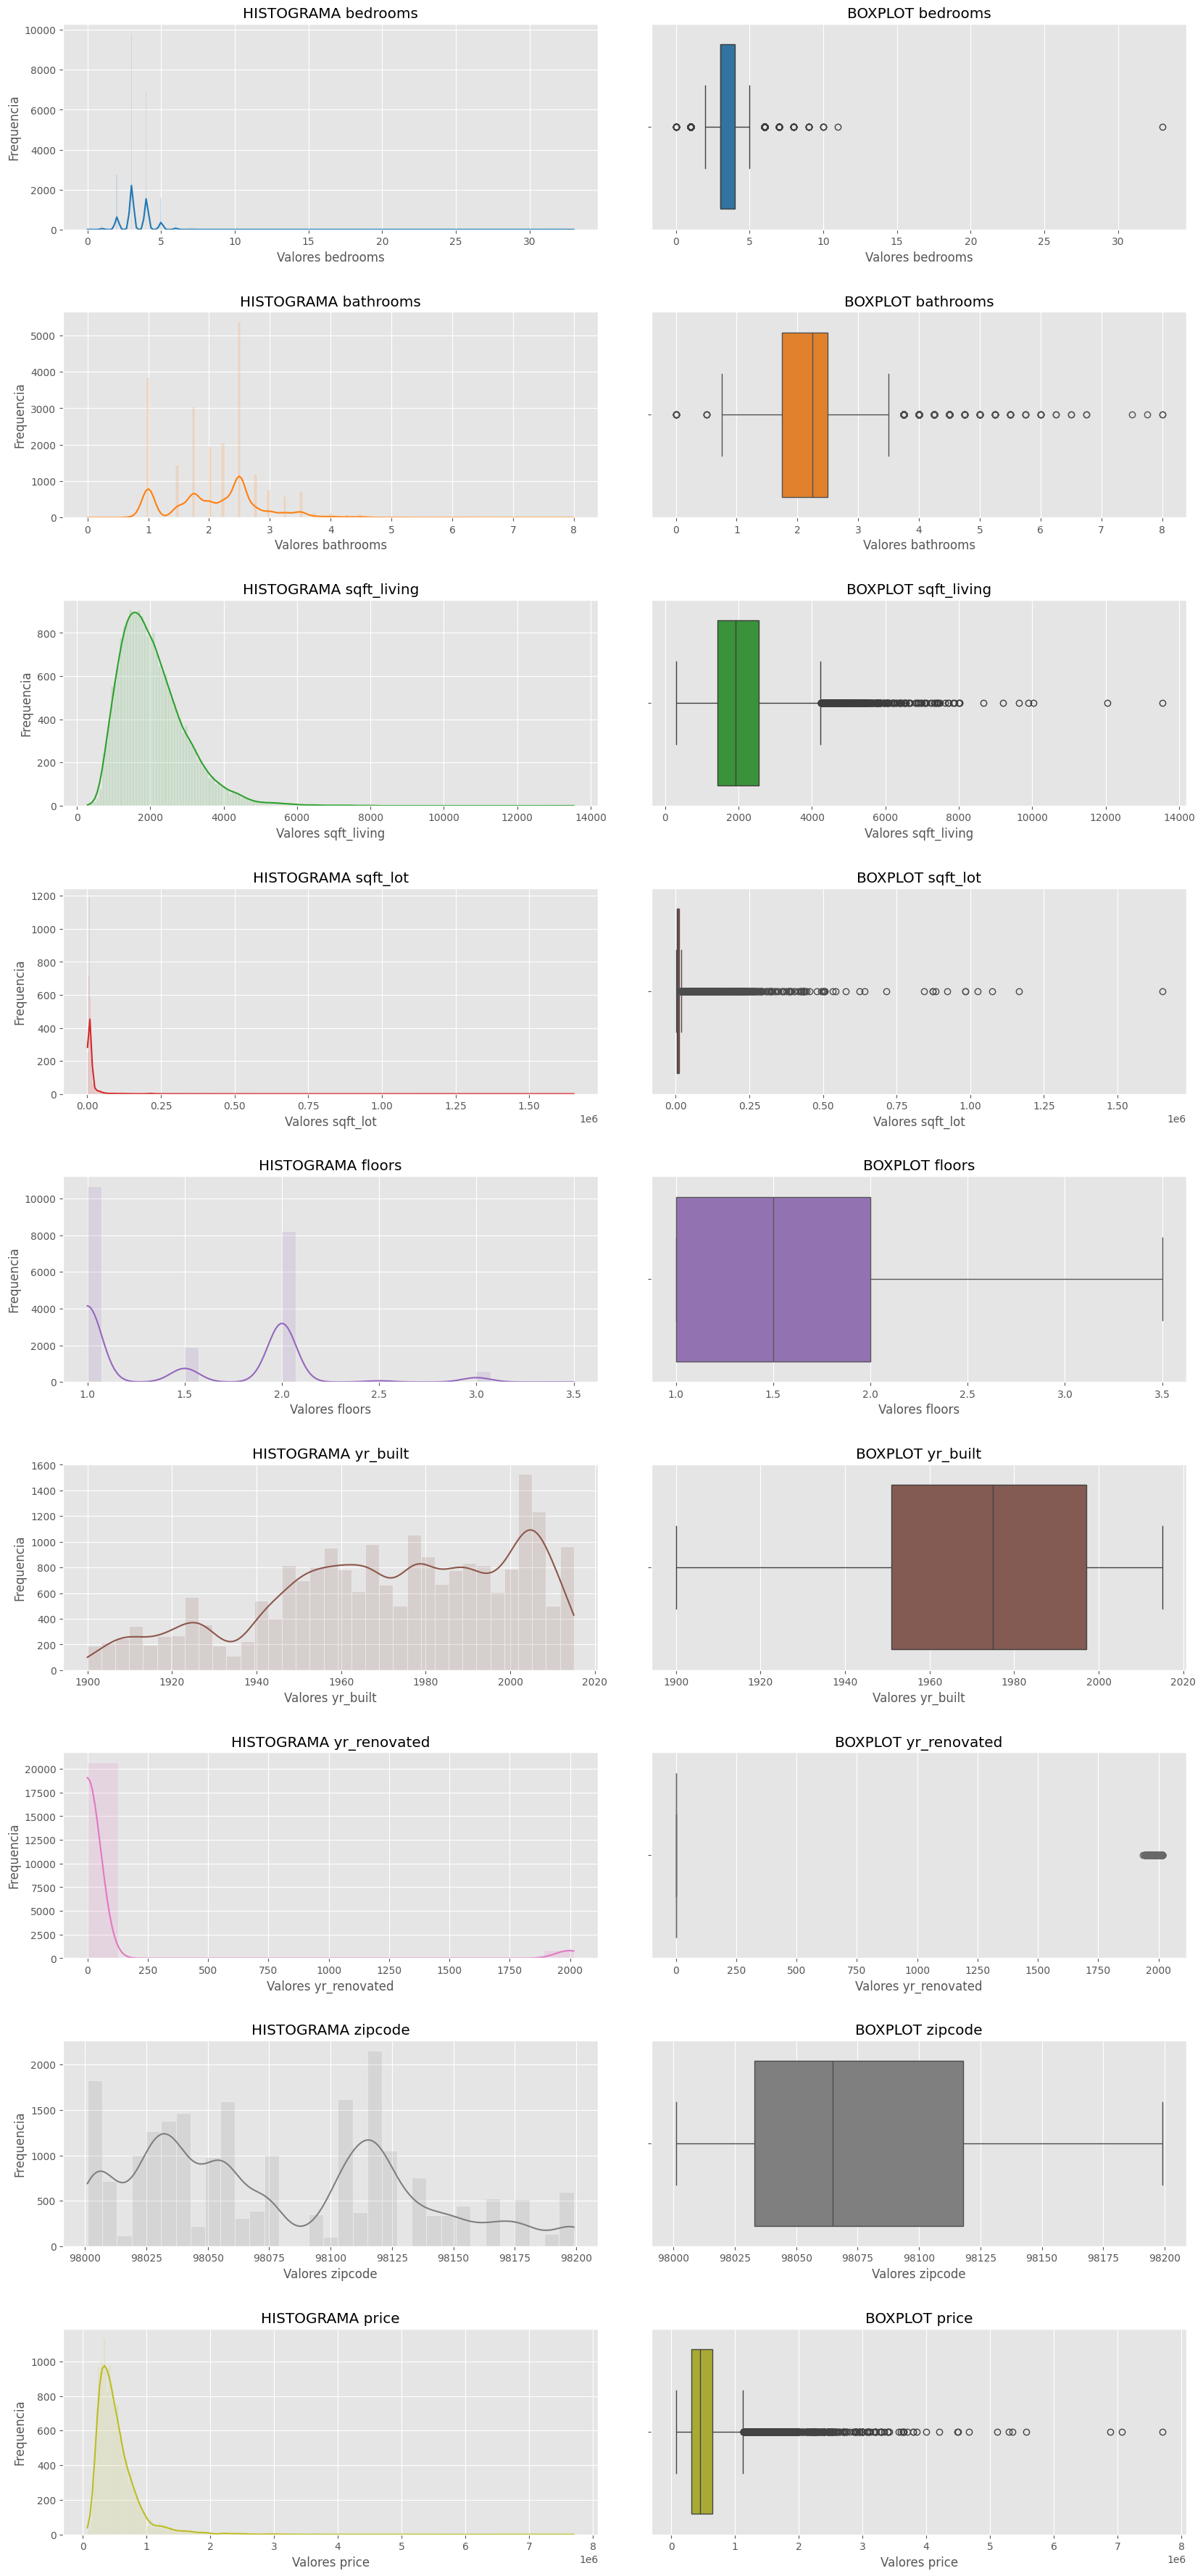

In [16]:
graf_histo_box_numericas(df_house, var_numericas)

## Columna yr_renovated atípicos muy extremos y en cantidad mínima

In [17]:
# recuperamos los datos
atipicos_renovated = df_house.yr_renovated[df_house.yr_renovated>1850]

# ¿cuantos hay?
len(atipicos_renovated)


913

<Axes: >

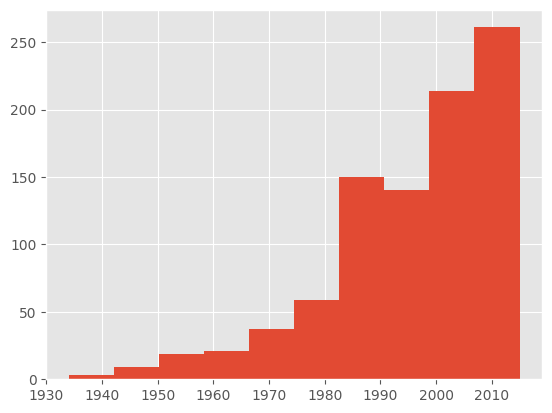

In [18]:
atipicos_renovated.hist()

## APARTADO: ejemplo de uso del método de numpy np.where.
En este caso, cambiar valor cero (año de renovacion cero=no renovado) y minoria de valores distintos de cero

In [19]:
# np.where(condicion, valor a sustituir si VERDADERO, valor a sustituir si FALSO)
df_house['reforma'] = np.where(df_house.yr_renovated==0,'NO REFORMADO', 'REFORMADO')

df_house.reforma.value_counts()

,count
reforma,
NO REFORMADO,20692
REFORMADO,913


Seguimos con el mismo problema, valor unico o categoria en categórica con muy poca representación, no queda otra opción

In [20]:
df_house.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'yr_built', 'yr_renovated', 'zipcode', 'price',
       'reforma'],
      dtype='object')

#### Eliminamos columna "yr_renovated" y "reforma" por no aportar información

In [21]:
df_house.drop(columns=['yr_renovated', 'reforma'], inplace=True)

df_house.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'yr_built', 'zipcode', 'price'],
      dtype='object')

In [22]:
var_numericas

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'price']

In [23]:
var_numericas.remove('yr_renovated')

var_numericas

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'yr_built',
 'zipcode',
 'price']

## Gráficas categórica

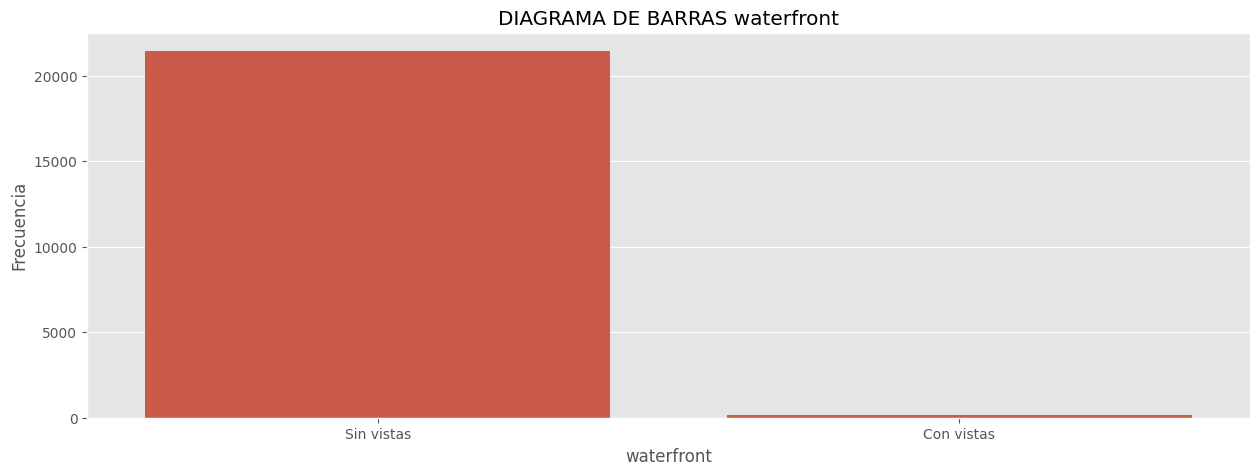

In [24]:
fig, ax = plt.subplots(len(var_categoricas), 1, figsize=(15, 5 * len(var_categoricas)))


for idx, columna in enumerate(var_categoricas):

    sns.countplot(x=columna, data=df_house, ax=ax)

    ax.set_title(f'DIAGRAMA DE BARRAS {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Frecuencia')

In [25]:
df_house.waterfront.value_counts()

,count
waterfront,
Sin vistas,21442
Con vistas,163


- De nuevo al eliminar la categoria con poca representación, ya la columna no ofrece información (columna constante)

#### Eliminar columna "waterfront"

In [26]:
df_house.drop(columns='waterfront', inplace=True)

df_house.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'yr_built', 'zipcode', 'price'],
      dtype='object')

In [27]:
var_categoricas

['waterfront']

In [28]:
var_categoricas.remove('waterfront')

var_categoricas

[]

# ANALISIS BIDIMENSIONAL

## Numérico-numérico

In [29]:
var_numericas

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'yr_built',
 'zipcode',
 'price']

### Multidimensional (numericas): sns.pairplot

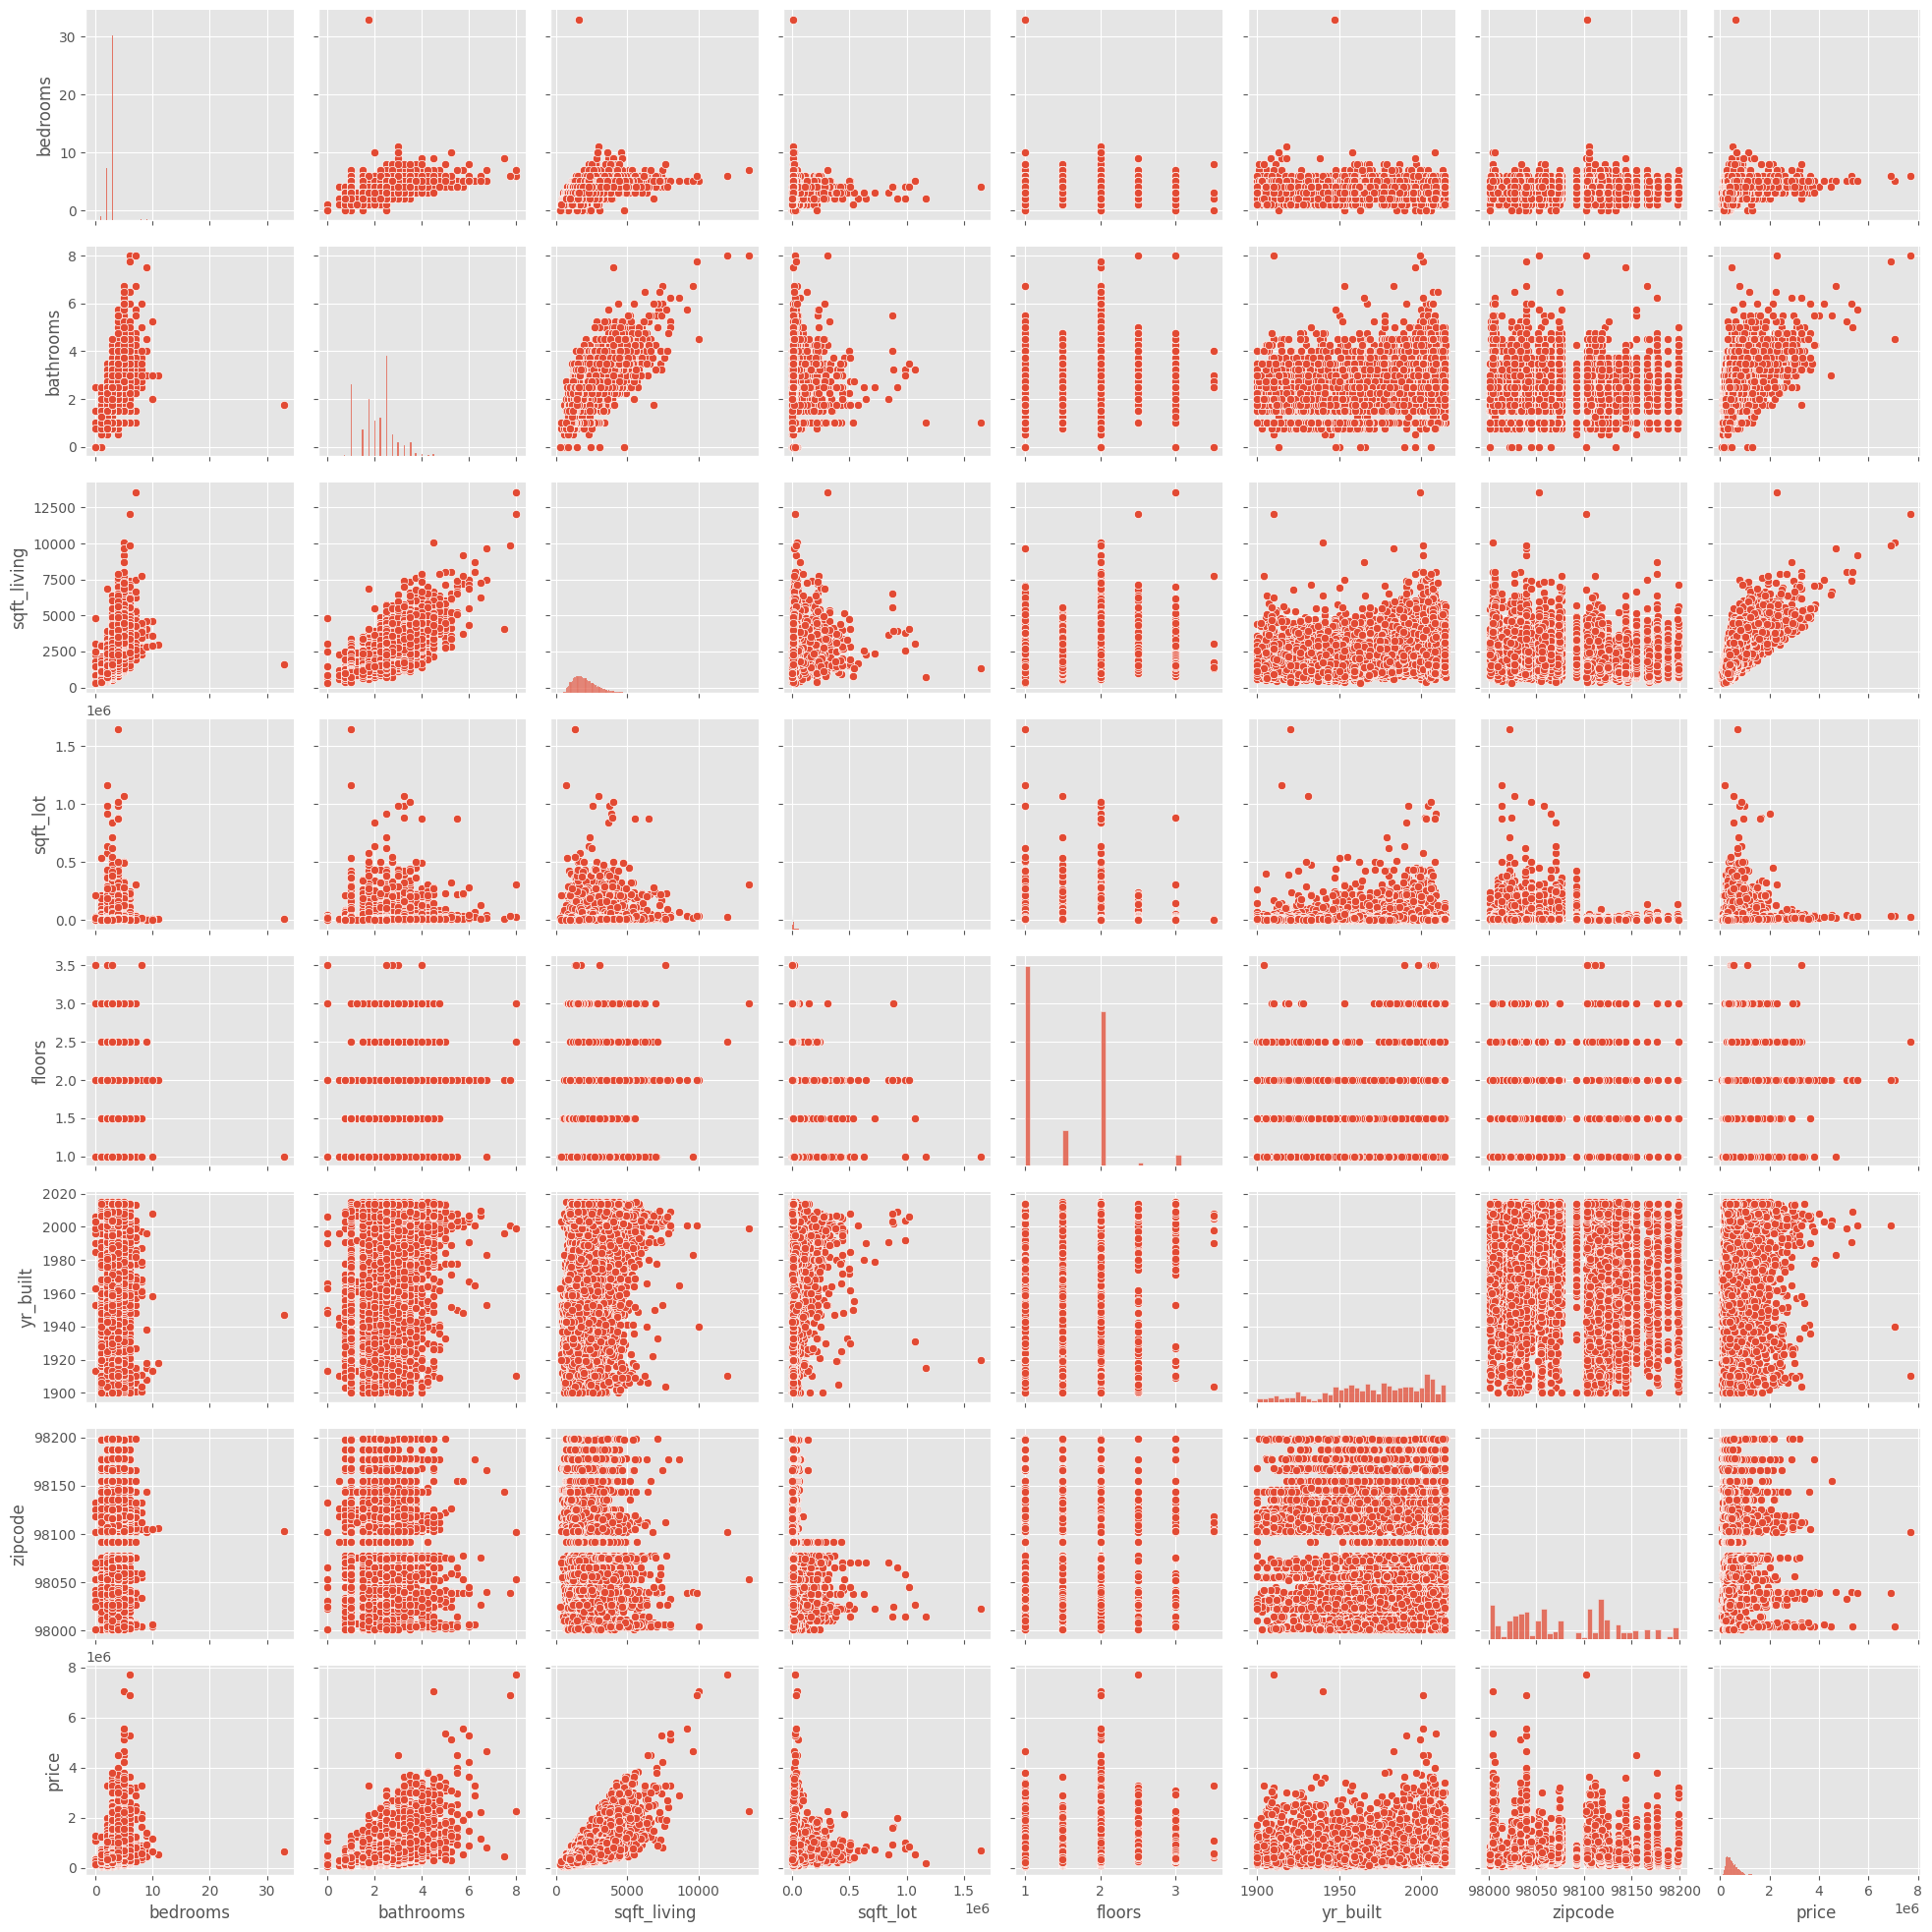

In [30]:
sns.pairplot(df_house[var_numericas])

- Siempre podemos ver alguna gráfica de las anteriores con mas detalle

<Axes: xlabel='bedrooms', ylabel='price'>

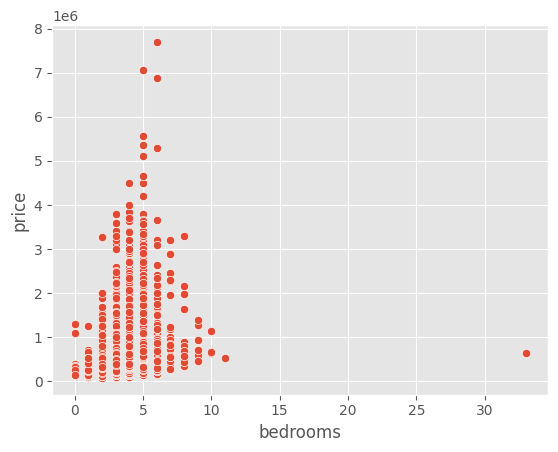

In [31]:
sns.scatterplot(x='bedrooms', y='price', data=df_house)

<Axes: xlabel='bedrooms', ylabel='price'>

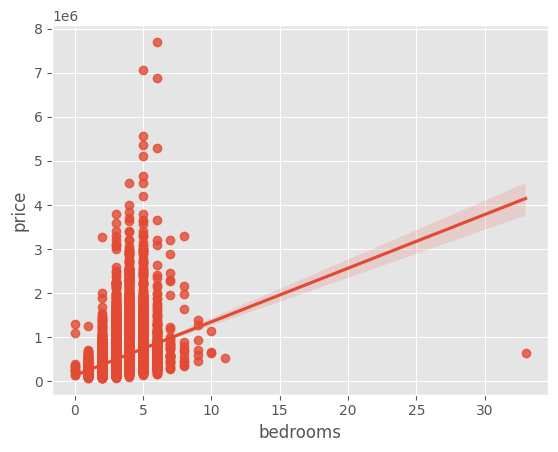

In [32]:
sns.regplot(x='bedrooms', y='price', data=df_house)

En este caso vemos como el valor extremo afecta mucho a los modelos lineales (lo retomaremos en eel tema 3)

### Matriz de correlación

In [33]:
# calculamos la correlacion (metodo "corr") del dataframe de columnas numéricas
mat_corr = df_house.corr(numeric_only=True)

mat_corr

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,yr_built,zipcode,price
bedrooms,1.000000,0.516013,0.576688,0.031696,0.175691,0.154401,-0.152804,0.308427
bathrooms,0.516013,1.000000,0.754735,0.087760,0.500891,0.506086,-0.203865,0.525167
sqft_living,0.576688,0.754735,1.000000,0.172799,0.354337,0.318358,-0.199379,0.702057
sqft_lot,0.031696,0.087760,0.172799,1.000000,-0.005044,0.053227,-0.129572,0.089653
floors,0.175691,0.500891,0.354337,-0.005044,1.000000,0.489109,-0.059289,0.256941
yr_built,0.154401,0.506086,0.318358,0.053227,0.489109,1.000000,-0.347105,0.054076
zipcode,-0.152804,-0.203865,-0.199379,-0.129572,-0.059289,-0.347105,1.000000,-0.053179
price,0.308427,0.525167,0.702057,0.089653,0.256941,0.054076,-0.053179,1.000000


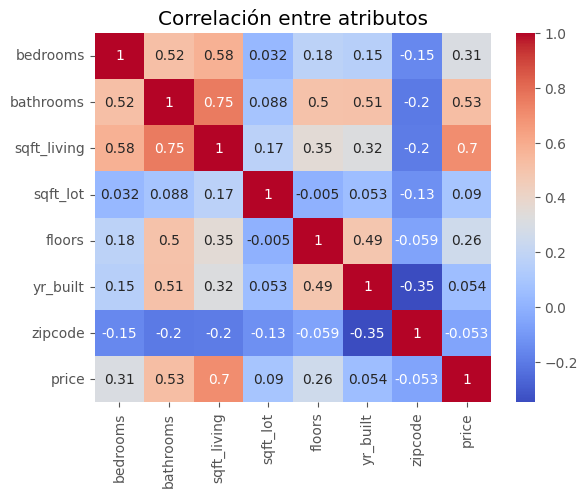

In [34]:
# mapa de calor (heatmap) para representar gráficamente la matriz de correlación

sns.heatmap(mat_corr, annot=True, cbar=True, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos');


- Vemos correlación entre 'bathrooms' y 'sqft_living'. Podemos eliminar una (aporta similar info). Eliminamos la que tiene menor correlación con el TARGET 'price'

#### Eliminamos "bathrooms"

In [35]:
df_house.drop(columns='bathrooms', inplace=True)

var_numericas.remove('bathrooms')

df_house.columns

Index(['bedrooms', 'sqft_living', 'sqft_lot', 'floors', 'yr_built', 'zipcode',
       'price'],
      dtype='object')

# TRATAMIENTO DE NULOS.

In [36]:
df_house.isnull().sum()

,0
bedrooms,0
sqft_living,0
sqft_lot,0
floors,0
yr_built,0
zipcode,0
price,0


# OUTLIERS

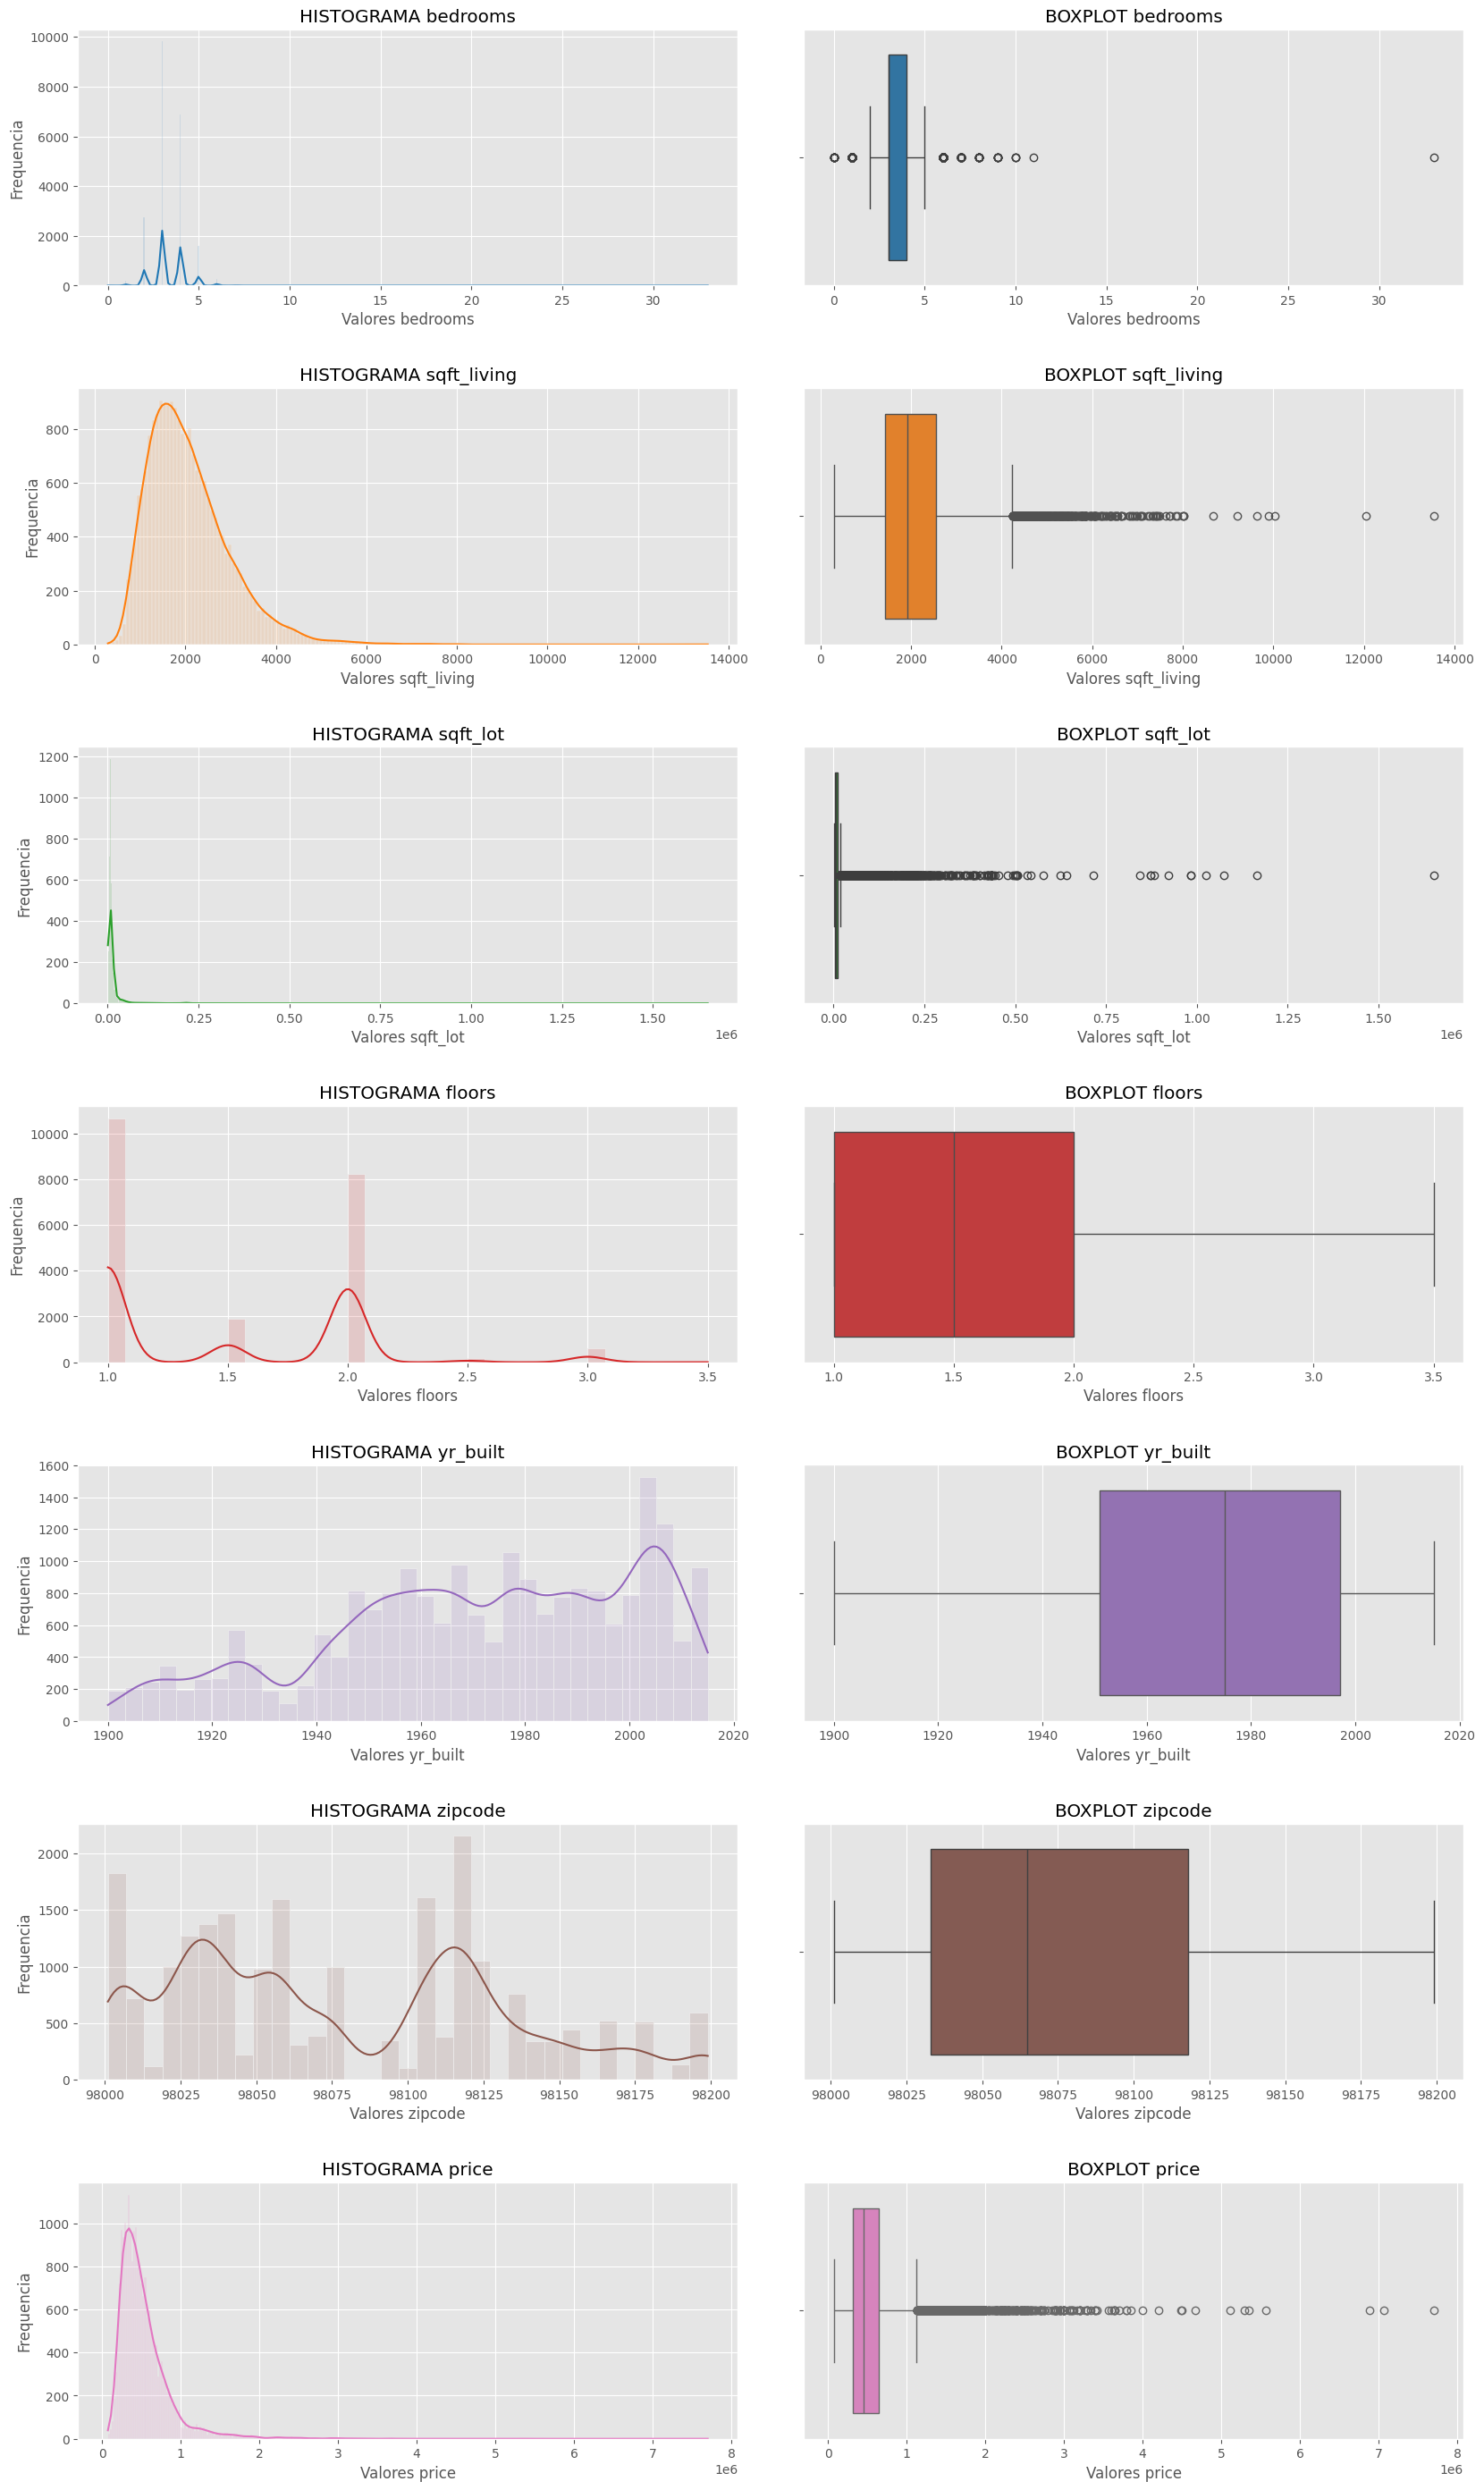

In [37]:
graf_histo_box_numericas(df_house, var_numericas)

### BEDROMS: valor mayor que 30

In [38]:
len(df_house[df_house.bedrooms>30])

1

In [39]:
df_house[df_house.bedrooms>30]

,bedrooms,sqft_living,sqft_lot,floors,yr_built,zipcode,price
15870,33,1620,6000,1.0,1947,98103,640000.0


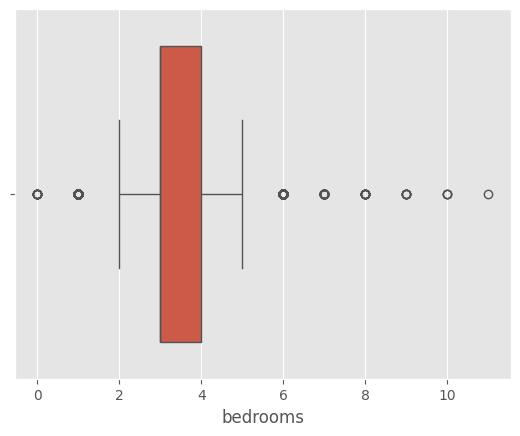

In [40]:
df_sin_outl_bedrooms = df_house[df_house.bedrooms<30]

sns.boxplot(x='bedrooms', data=df_sin_outl_bedrooms);

**Eliminariamos la fila sin problema**

### Campos AREAS y PRECIO: ver nºocurrencias

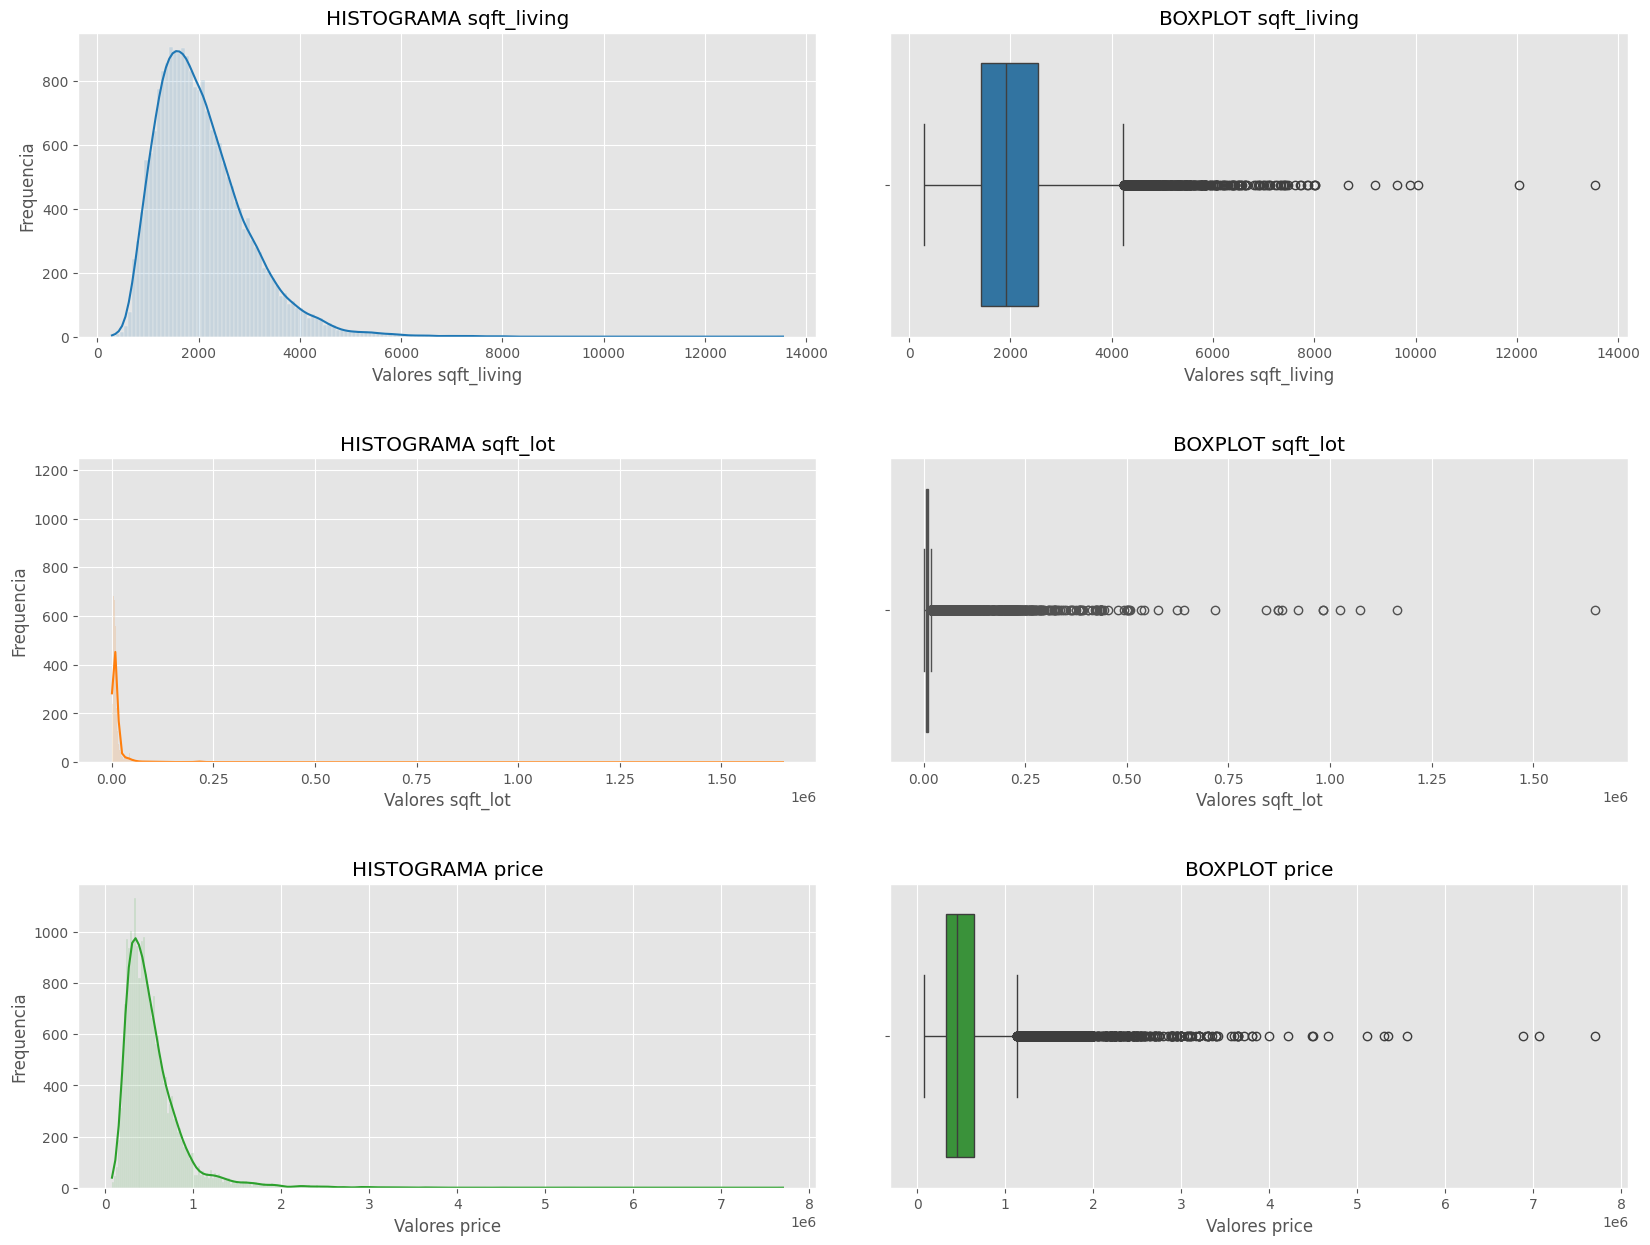

In [41]:
graf_histo_box_numericas(df_house, ['sqft_living', 'sqft_lot', 'price'])

**OUTLIERS MAS ALEJADOS**

-  sqft_living

In [42]:
len(df_house[df_house.sqft_living>8000])

9

In [43]:
casas1= set(df_house[df_house.sqft_living>8000].index)

casas1

{1164, 3914, 4411, 7252, 8092, 9254, 12777, 14556, 18302}

-  sqft_lot


In [44]:
len(df_house[df_house.sqft_lot>0.55e6])

15

In [45]:
casas2= set(df_house[df_house.sqft_lot>0.55e6].index)

casas2

{1719,
 3949,
 4441,
 4540,
 6691,
 7077,
 7294,
 7647,
 7769,
 9714,
 13006,
 13477,
 16188,
 17319,
 20452}

-  price:

In [46]:
len(df_house[df_house.price>4e6])

11

In [47]:
casas3= set(df_house[df_house.price>4e6].index)

casas3

{1164, 1315, 1448, 2626, 3914, 4411, 7252, 8092, 8638, 9254, 12370}

In [48]:
casas1.intersection(casas2)

set()

In [49]:
casas1.intersection(casas3)

{1164, 3914, 4411, 7252, 8092, 9254}

In [50]:
casas2.intersection(casas3)

set()

En el tramo de outliers mas extremos tenemos pocas filas en cada una de las 3, ademas tienen elementos en común en las 3 columnas entre esos oUtliers. **LAS PODEMOS ELIMINAR EN LAS 3 COLUMNAS (DESDE LOS LIMITES ELEGIDOS)**

In [51]:
idx1 = df_house[df_house.sqft_living>8000].index

df_house.drop(index=idx1, inplace=True)



In [52]:
idx2 = df_house[df_house.sqft_lot>0.55e6].index

df_house.drop(index=idx2, inplace=True)

In [53]:
idx3 = df_house[df_house.price>4e6].index

df_house.drop(index=idx3, inplace=True)

- **OUTLIERS MAS PROXIMOS**

In [54]:
lim_inf, lim_sup = calculos_boxplot(df_house.price)

lim_sup

Cuartiles:  321000.0 	 643000.5
IQR:  322000.5
Limite inferior:  -162000.75
Limite superior:  1126001.25


1126001.25

In [55]:
df_house.price[(df_house.price>lim_sup) & (df_house.price<4e6)]

,price
5,1225000.0
21,2000000.0
49,1350000.0
69,1325000.0
125,1450000.0
...,...
21568,1700000.0
21576,3567000.0
21590,1222500.0
21597,1575000.0


In [56]:
len(df_house.price[(df_house.price>lim_sup) & (df_house.price<4e6)])

1130

In [57]:
mas_cercanos = df_house.price[(df_house.price>lim_sup) & (df_house.price<4e6)]

mas_cercanos.describe()

,price
count,1.130000e+03
mean,1.623166e+06
std,5.133487e+05
min,1.127000e+06
25%,1.258500e+06
50%,1.450000e+06
75%,1.800000e+06
max,3.850000e+06


El grupo de outliers más cercano es ya considerable en número, y sus valores no se pueden considerar como no posibles, **NO SE PUEDEN CONSIDERAR ERRORES.**

**POR LO TANTO CONSERVAMOS ESTOS VALORES.**


# **Situación similar la encontramos en las otras dos columnas**

In [60]:
lim_inf, lim_sup = calculos_boxplot(df_house.sqft_living)


Cuartiles:  1420.0 	 2550.0
IQR:  1130.0
Limite inferior:  -275.0
Limite superior:  4245.0


In [61]:
df_house.sqft_living[(df_house.sqft_living>lim_sup) & (df_house.sqft_living<8000)]

,sqft_living
5,5420
70,4770
115,4380
153,5180
239,4410
...,...
21551,4350
21561,4500
21576,4850
21590,4910


In [62]:
len(df_house.sqft_living[(df_house.sqft_living>lim_sup) & (df_house.sqft_living<8000)])

549

In [63]:
mas_cercanos2 = df_house.sqft_living[(df_house.sqft_living>lim_sup) & (df_house.sqft_living<8000)]

mas_cercanos2.describe()

,sqft_living
count,549.000000
mean,4967.285974
std,741.426510
min,4250.000000
25%,4420.000000
50%,4690.000000
75%,5310.000000
max,7880.000000


In [64]:
lim_inf, lim_sup = calculos_boxplot(df_house.sqft_lot)


Cuartiles:  5040.0 	 10652.75
IQR:  5612.75
Limite inferior:  -3379.125
Limite superior:  19071.875


In [66]:
df_house.sqft_lot[(df_house.sqft_lot>lim_sup) & (df_house.sqft_lot<0.55e6)]

,sqft_lot
5,101930
12,19901
21,44867
36,34848
41,24186
...,...
21494,62726
21506,130017
21520,50621
21525,108865


In [67]:
len(df_house.sqft_lot[(df_house.sqft_lot>lim_sup) & (df_house.sqft_lot<0.55e6)])

2407

In [68]:
mas_cercanos3 = df_house.sqft_lot[(df_house.sqft_lot>lim_sup) & (df_house.sqft_lot<0.55e6)]

mas_cercanos3.describe()

,sqft_lot
count,2407.000000
mean,70827.120482
std,78470.693565
min,19080.000000
25%,26555.500000
50%,39634.000000
75%,72309.000000
max,542322.000000
